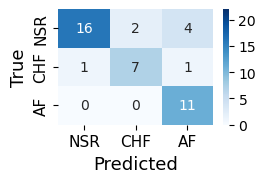

SVM Test Accuracy: 0.7974 ± 0.0580
AF Sensitivity: 0.8250 ± 0.0870
AF Specificity: 0.8690 ± 0.0894
CHF Sensitivity: 0.6944 ± 0.1486
CHF Specificity: 0.9312 ± 0.0426
NSR Sensitivity: 0.8264 ± 0.1207
NSR Specificity: 0.8832 ± 0.0589
balaced_accuracy: 0.7819 ± 0.0671


In [5]:
import numpy as np
import pandas as pd
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams  # this helps to change fonts (custom use)
import inspect
from sklearn.multiclass import OneVsRestClassifier 
import math

# LaTeX rendering for labels (optional)
plt.rcParams['text.usetex'] = False

# Step 1: Load data from files
def load_data(filepath):
    return np.loadtxt(filepath)

# Load burstiness
burst_nsr = load_data('burstiness_nsr.txt')
burst_chf = load_data('burstiness_chf.txt')
burst_af = load_data('burstiness_af.txt')

# Load memory
mem_nsr = load_data('memory_iet_nsr.txt')
mem_chf = load_data('memory_iet_chf.txt')
mem_af = load_data('memory_iet_af.txt')

# Load time scale
ts_nsr = load_data('Dt_interval_nsr.txt')
ts_chf = load_data('Dt_interval_chf.txt')
ts_af = load_data('Dt_interval_af.txt')

#load delta peak
peak_nsr = load_data('original_Delta_peak_700_nsr.txt') 
peak_chf = load_data('original_Delta_peak_700_chf.txt') 
peak_af = load_data('original_Delta_peak_700_af.txt') 

# Step 2: Create dataset
data = []
labels = []

# Our labeling: 0=AF, 1=CHF, 2=NSR
for b, m, t, p in zip(burst_af, mem_af, ts_af, peak_af):
    data.append([b, m, t, p])
    labels.append(0)  
for b, m, t, p in zip(burst_chf, mem_chf, ts_chf, peak_chf):
    data.append([b, m, t, p])
    labels.append(1)  
for b, m, t, p in zip(burst_nsr, mem_nsr, ts_nsr, peak_nsr):
    data.append([b, m, t, p])
    labels.append(2)  

X = np.array(data)
y = np.array(labels)

# Normalize features (Since the features have different scales)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Number of runs as n_runs
n_runs = 100  # We can use different values for our statistics
accuracy_list = []
balanced_accuracy_list = []
sens_af_list = []
spec_af_list = []
sens_chf_list = []
spec_chf_list = []
sens_nsr_list = []
spec_nsr_list = []


for run in range(n_runs):
    # Step 3: Train-test split 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

    # Step 3_1: Hyperparameter Tuning for SVM with OvR
    param_grid = {'estimator__C': [0.01, 0.1, 1, 10, 100], 'estimator__gamma': [0.001, 0.01, 0.1, 1, 10]}  # Note that: Prefix with 'estimator__' for nested params in OneVsRestClassifier
    svm_model = OneVsRestClassifier(svm.SVC(kernel='rbf', class_weight='balanced'))  
    grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='accuracy', verbose=0)  # Set verbose=0 to reduce output
    grid_search.fit(X_train, y_train)
    
    clf_svm = grid_search.best_estimator_

    # Step 4: Evaluate SVM
    y_pred_svm = clf_svm.predict(X_test)
  
    acc = accuracy_score(y_test, y_pred_svm)
    accuracy_list.append(acc)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred_svm)
    
    # Print the confusion matrix for the first run for visualization
    if run == 0:
        max_val = np.max(cm)
        plt.figure(figsize=(2.5, 1.5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NSR', 'CHF', 'AF'], yticklabels=['NSR', 'CHF', 'AF'],vmin = 0, vmax = 22, cbar_kws={'ticks': np.arange(0, 25, 5)})
        rcParams["font.family"] = "sans-serif"
        
        #Fonts
        plt.xticks(fontsize=11)
        plt.yticks(fontsize=11)
        plt.xlabel('Predicted', fontsize=13)
        plt.ylabel('True', fontsize=13)

        #Colorbar label font
        cbar = plt.gca().collections[0].colorbar
        cbar.ax.tick_params(labelsize=10)
        #cbar.set_label("Count", fontsize=14)
        #plt.title('SVM Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.savefig('confusion_matrix.pdf', bbox_inches='tight') 
        plt.show()
        plt.rcParams['text.usetex'] = True

     
    # Calculate sensitivity and specificity for each class using precision_recall_fscore_support
    res = []
    for l in [0, 1, 2]:
        prec, recall, _, _ = precision_recall_fscore_support(np.array(y_test) == l,
                                                             np.array(y_pred_svm) == l,
                                                             pos_label=True, average=None)
        res.append([l, recall[0], recall[1]])  # recall[0] is specificity (for negative class), recall[1] is sensitivity (for positive class)
    
    #Note that: res will disply like this [class, specificity, sensitivity] [[0 or1 or 2], 1, 2] 
    # Append to lists: res[0][1] is spec for AF, res[0][2] is sens for AF, etc.
    sens_af_list.append(res[0][2])  # sensitivity for AF
    spec_af_list.append(res[0][1])  # specificity for AF
    sens_chf_list.append(res[1][2])  # sensitivity for CHF
    spec_chf_list.append(res[1][1])  # specificity for CHF
    sens_nsr_list.append(res[2][2])  # sensitivity for NSR
    spec_nsr_list.append(res[2][1])  # specificity for NSR
    balanced_accuracy_list.append((res[0][2] + res[1][2] + res[2][2])/3.0)

# Compute mean and std of the accuracies
accuracy_mean = np.mean(accuracy_list)
accuracy_std = np.std(accuracy_list)

#Compute mean and std of the balanced accuracies
balanced_mean = np.mean(balanced_accuracy_list)
balanced_std = np.std(balanced_accuracy_list)

# Compute mean and std of sensitivities and specificities for each class
sens_af_mean = np.mean(sens_af_list)
sens_af_std = np.std(sens_af_list)
spec_af_mean = np.mean(spec_af_list)
spec_af_std = np.std(spec_af_list)

sens_chf_mean = np.mean(sens_chf_list)
sens_chf_std = np.std(sens_chf_list)
spec_chf_mean = np.mean(spec_chf_list)
spec_chf_std = np.std(spec_chf_list)

sens_nsr_mean = np.mean(sens_nsr_list)
sens_nsr_std = np.std(sens_nsr_list)
spec_nsr_mean = np.mean(spec_nsr_list)
spec_nsr_std = np.std(spec_nsr_list)


# Print average accuracy
print(f"SVM Test Accuracy: {accuracy_mean:.4f} ± {accuracy_std:.4f}")

# Print sensitivities, specificities and balanced accuracy
print(f"AF Sensitivity: {sens_af_mean:.4f} ± {sens_af_std:.4f}")
print(f"AF Specificity: {spec_af_mean:.4f} ± {spec_af_std:.4f}")
print(f"CHF Sensitivity: {sens_chf_mean:.4f} ± {sens_chf_std:.4f}")
print(f"CHF Specificity: {spec_chf_mean:.4f} ± {spec_chf_std:.4f}")
print(f"NSR Sensitivity: {sens_nsr_mean:.4f} ± {sens_nsr_std:.4f}")
print(f"NSR Specificity: {spec_nsr_mean:.4f} ± {spec_nsr_std:.4f}")
print(f"balaced_accuracy: {balanced_mean:.4f} ± {balanced_std:.4f}")
